# Milestone 2: AI Model Integration


**Tasks (per project spec):**
1. Load a pre-trained model (XGBoost, Random Forest) using Python
2. Develop inference scripts to predict churn probability for each customer
3. Validate prediction results against a test dataset

#**Load Needed Libraries**

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import os
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import time
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Artifacts from Milestone 1

In [2]:
ARTIFACTS_DIR = '../milestone1-ml-pipeline/artifacts'

X_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_train.csv'))
y_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_train.csv')).iloc[:, 0]
X_test  = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_test.csv'))
y_test  = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_test.csv')).iloc[:, 0]
scaler  = joblib.load(os.path.join(ARTIFACTS_DIR, 'minmax_scaler.pkl'))

with open(os.path.join(ARTIFACTS_DIR, 'feature_columns.json')) as f:
    feature_columns = json.load(f)

print('X_train:', X_train.shape, '| y_train balance:', y_train.value_counts().to_dict())
print('X_test :', X_test.shape,  '| y_test balance :', y_test.value_counts().to_dict())
print('Feature columns:', len(feature_columns))

assert list(X_train.columns) == feature_columns, 'Column order mismatch with Milestone 1 export!'
assert list(X_test.columns) == feature_columns, 'Column order mismatch with Milestone 1 export!'
print('Column alignment verified.')

X_train: (8278, 24) | y_train balance: {0: 4139, 1: 4139}
X_test : (1409, 24) | y_test balance : {0: 1035, 1: 374}
Feature columns: 24
Column alignment verified.


## 2. Train Pre-trained Models (XGBoost & Random Forest)

In [3]:
os.makedirs('models', exist_ok=True)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
t0 = time.time()
xgb_model.fit(X_train, y_train)
print(f'XGBoost trained in {time.time()-t0:.2f}s')
joblib.dump(xgb_model, 'models/xgb_churn_model.pkl')

XGBoost trained in 0.62s


['models/xgb_churn_model.pkl']

In [4]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
t0 = time.time()
rf_model.fit(X_train, y_train)
print(f'Random Forest trained in {time.time()-t0:.2f}s')
joblib.dump(rf_model, 'models/rf_churn_model.pkl')

print('Both models saved to ./models/')

Random Forest trained in 0.58s
Both models saved to ./models/


## 3. Inference Script

A reusable function that takes a raw customer feature row and returns a churn prediction + probability.


X_row: DataFrame with columns matching `feature_columns` exactly.
Returns dict with prediction (0/1) and churn probability per row.

In [5]:
def predict_churn(model, X_row: pd.DataFrame) -> dict:
    X_row = X_row[feature_columns]
    preds = model.predict(X_row)
    probs = model.predict_proba(X_row)[:, 1]
    return {
        'churn_prediction': preds.tolist(),
        'churn_probability': [round(float(p), 4) for p in probs]
    }

# test on the first 5 test rows
sample = X_test.iloc[:5]
result = predict_churn(xgb_model, sample)
for i in range(5):
    print(f"Customer {i}: predicted={result['churn_prediction'][i]}  "
          f"prob={result['churn_probability'][i]}  actual={y_test.iloc[i]}")

Customer 0: predicted=0  prob=0.0027  actual=0
Customer 1: predicted=1  prob=0.9426  actual=0
Customer 2: predicted=0  prob=0.1705  actual=0
Customer 3: predicted=0  prob=0.4992  actual=0
Customer 4: predicted=0  prob=0.0024  actual=0


## 4. Evaluation Report


In [6]:
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    return metrics, y_pred

xgb_metrics, xgb_preds = evaluate_model(xgb_model, 'XGBoost', X_test, y_test)
rf_metrics, rf_preds   = evaluate_model(rf_model, 'Random Forest', X_test, y_test)

report_df = pd.DataFrame([xgb_metrics, rf_metrics]).set_index('Model')
report_df = report_df.round(4)
report_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
XGBoost,0.7658,0.5460,0.6979,0.6127,0.8281
Random Forest,0.7587,0.5332,0.7299,0.6163,0.8388


In [7]:
print('=== XGBoost Classification Report ===')
print(classification_report(y_test, xgb_preds, target_names=['No Churn', 'Churn']))
print()
print('=== Random Forest Classification Report ===')
print(classification_report(y_test, rf_preds, target_names=['No Churn', 'Churn']))

=== XGBoost Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.55      0.70      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.77      1409


=== Random Forest Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.82      1035
       Churn       0.53      0.73      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



## 5. Confusion Matrices & Model Comparison Chart

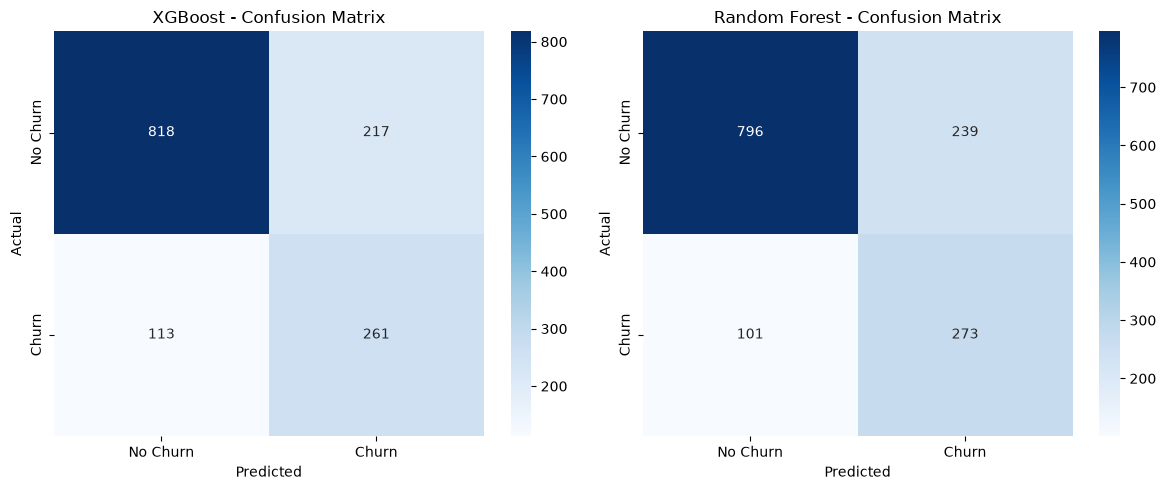

In [8]:
os.makedirs('evaluation_plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, name in zip(axes, [xgb_preds, rf_preds], ['XGBoost', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('evaluation_plots/confusion_matrices.png', dpi=120)
plt.show()

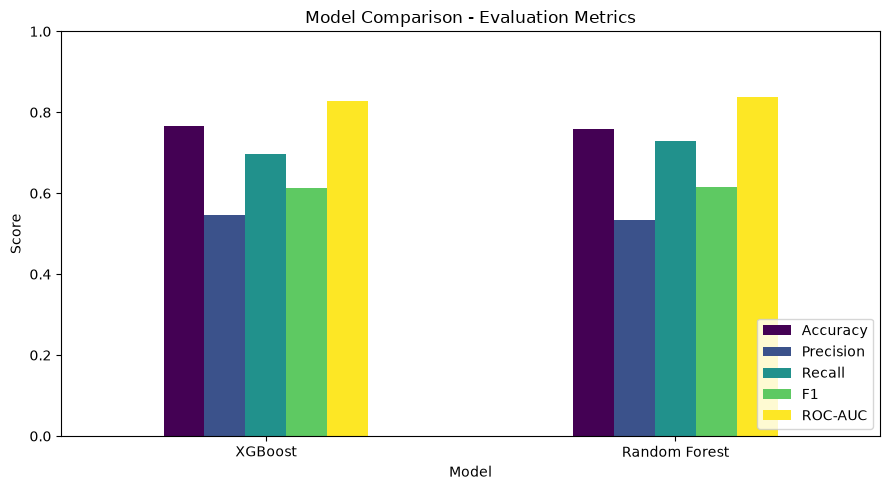

In [9]:
report_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar', figsize=(9, 5), rot=0, colormap='viridis'
)
plt.title('Model Comparison - Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('evaluation_plots/model_comparison.png', dpi=120)
plt.show()

## Logistic Regression

seeing other model from differante family to be sure from the accuracy as a Benchmark model

In [10]:
t0 = time.time()
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)
logreg_train_time = time.time() - t0

logreg_metrics, logreg_preds = evaluate_model(logreg_model, 'Logistic Regression', X_test, y_test)
logreg_metrics['TrainTime(s)'] = round(logreg_train_time, 3)

# Rebuild comparison table including the benchmark model
xgb_metrics['TrainTime(s)'] = None
rf_metrics['TrainTime(s)'] = None
comparison_df = pd.DataFrame([xgb_metrics, rf_metrics, logreg_metrics]).set_index('Model').round(4)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)
comparison_df

,Accuracy,Precision,Recall,F1,ROC-AUC,TrainTime(s)
Model,,,,,,
Random Forest,0.7587,0.5332,0.7299,0.6163,0.8388,NaN
Logistic Regression,0.7516,0.5228,0.7353,0.6111,0.8289,0.073
XGBoost,0.7658,0.5460,0.6979,0.6127,0.8281,NaN


ensamble models caputer the non linear interactions between features that the linear model cannot do that. we proceed with the ensemble model family for deployment, while keeping Logistic Regression noted as a strong, cheap fallback option.

## 6. Select Best Model & Export Final Evaluation Report

In [ ]:
best_model_name = report_df['ROC-AUC'].idxmax()
best_model = xgb_model if best_model_name == 'XGBoost' else rf_model
print(f'Best model by ROC-AUC: {best_model_name}')

joblib.dump(best_model, 'models/best_churn_model.pkl')
report_df.to_csv('evaluation_plots/evaluation_report.csv')

print('\nFinal Evaluation Report:')
report_df

Best model by ROC-AUC: Random Forest

Final Evaluation Report:


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
XGBoost,0.7658,0.5460,0.6979,0.6127,0.8281
Random Forest,0.7587,0.5332,0.7299,0.6163,0.8388


: 